# **20. 도로 영역을 찾자! - 세그멘테이션 모델 만들기**

## **20-1. 들어가며**

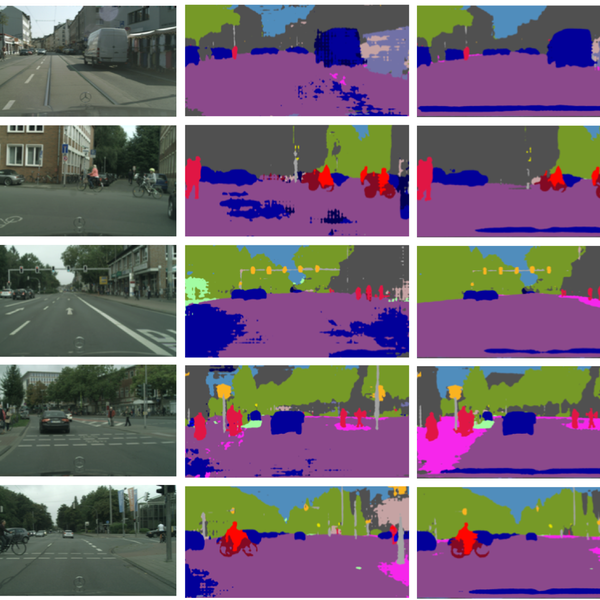

https://github.com/wasidennis/AdaptSegNet

**[아이스브레이킹] "유넷"으로 이행시를 지어보세요.**<br>
A. [ 답변을 적어볼까요! ]<br><br>

<details><summary>💡예시답안 확인하기💡</summary>

유 : 유례 없는 일이 벌어지고 있다. 유<br>
<br>
넷 : 넷과 함께하는 순간들은 항상 특별하다.</details>

이번 시간에는 Semantic Segmentation(시맨틱 세그멘테이션) 을 이용해서 자율주행차량이 주행해야 할 도로 영역을 찾는 상황을 가정하고 모델을 만들어보는 시간을 갖겠습니다. 앞서 강의 노드에서는 Semantic Segmentation을 위한 다양한 모델을 배워보았습니다. 이번 시간에는 U-Net을 사용해서 이미지가 입력되면 도로의 영역을 Segmentation 하는 모델을 만들어보겠습니다. \
\
최종적으로 만들어 볼 모델은 아래와 같습니다! 입력 이미지 위에 도로 영역으로 인식한 영역을 흰색으로 오버레이 한 이미지입니다.

<img src="https://d3s0tskafalll9.cloudfront.net/media/original_images/result.gif">

### **학습내용**
---

* 2. 시맨틱 세그멘테이션 데이터셋
  * Semantic Segmentation 학습을 위한 KITTI Dataset을 준비합니다.
* 3. 시맨틱 세그멘테이션 모델
  * U-Net model을 작성합니다.
* 4. 시맨틱 세그멘테이션 모델 시각화
  * 학습된 결과를 시각화합니다.

### **실습목표**
---

* 시맨틱 세그멘테이션 데이터셋을 전처리할 수 있습니다.
* 시맨틱 세그멘테이션 모델을 만들고 학습할 수 있습니다.
* 시맨틱 세그멘테이션 모델의 결과를 시각화할 수 있습니다.

## **20-2. 시맨틱 세그멘테이션 데이터셋**

### **이미지, 데이터 가져오기**
---

먼저 **시맨틱 세그멘테이션(semantic segmentation)** 으로 도로의 영역을 분리하기 위해서는 도로의 영역을 라벨로 가진 데이터셋을 가지고 학습할 수 있도록 파싱 해야 합니다. 아래 링크를 통해서 물체 검출(object detection)으로 사용했던 **KITTI 데이터셋의 세그멘테이션 데이터** 를 다운로드합니다. \
\
데이터 출처: http://www.cvlibs.net/datasets/kitti/eval_semantics.php



```
$ mkdir -p ~/aiffel/semantic_segmentation/data
$ wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
$ unzip data_semantics.zip -d ~/aiffel/semantic_segmentation/data
```



In [1]:
!mkdir -p ./aiffel/semantic_segmentation/data
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip data_semantics.zip -d ./aiffel/semantic_segmentation/data

--2026-09-03 05:33:23--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.136.188, 3.5.121.102, 16.12.24.25, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.136.188|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327699796 (313M) [application/zip]
Saving to: ‘data_semantics.zip’

data_semantics.zip  100%[===================>] 312.52M  20.1MB/s    in 17s     

2026-09-03 05:33:41 (17.9 MB/s) - ‘data_semantics.zip’ saved [327699796/327699796]

Archive:  data_semantics.zip
   creating: ./aiffel/semantic_segmentation/data/testing/
   creating: ./aiffel/semantic_segmentation/data/testing/image_2/
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000000_10.png  
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000001_10.png  
  inflating: ./aiffel/semantic_segmentation/data/testing/image_2/000002_10.png  

아래는 데이터셋에서 확인할 수있는 이미지와 라벨입니다. 지금까지 보던 라벨 데이터와 다르게 세그멘테이션 데이터는 이미지 형태의 라벨으로 되어있습니다.

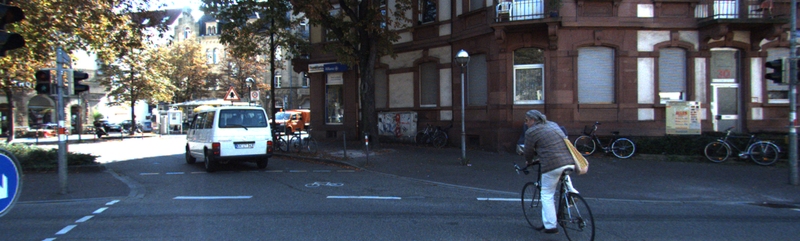

[KITTI 데이터셋]

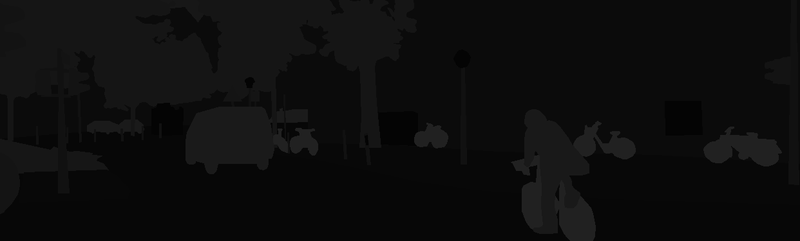

[KITTI 데이터셋 segmentation]

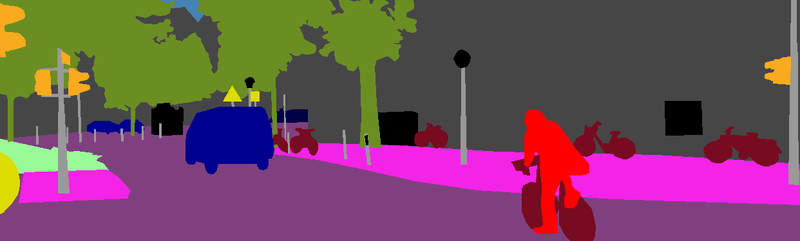

[KITTI 데이터셋 segmentation_rgb]

**Q. 시맨틱 세그멘테이션의 이미지 라벨의 각 pixel 값은 의미를 갖습니다. 그렇다면 오늘 우리가 시맨틱 세그멘테이션으로 찾아내야 할 도로의 label은 어떤 값일까요?**<br>
A. [ 답변을 적어볼까요! ]<br><br>
<details><summary>힌트</summary>

[라벨 정보](https://github.com/mcordts/cityscapesScripts/blob/master/cityscapesscripts/helpers/labels.py)를 참고하세요.</details>

<details><summary>💡예시답안 확인하기💡</summary>

7입니다.</details>

### **데이터 로더(data loader) 만들기**
---

이제 이미지와 데이터셋이 주어졌으니 모델을 학습시킬 수 있는 데이터 로더(data loader)를 만들어봅시다. 로더는 입력값 `(224, 224)`, 출력값 `(224, 244)` 크기를 갖는 모델을 학습시킬 수 있도록 데이터셋을 파싱 해야 합니다. \
\
이때 데이터 로더에 **augmentation** 을 적용해 봅시다. 오늘은 파이썬에서 많이 사용되는 `albumentations`을 사용해 보겠습니다. 하지만 Augmentation의 경우 `imgaug` 등 다른 라이브러리를 활용하셔도 됩니다.



```
$ pip install albumentations
```



In [2]:
!pip install albumentations

또한 학습셋의 일정량을 **검증 데이터셋(validation dataset)** 으로 활용할 수 있도록 해야 합니다. \
\
만든 후에는 직접 데이터셋이 잘 파싱 되어 나오는지 꼭 확인해보세요. 데이터셋에 오류가 없어야 성능이 안 나오더라도 문제를 찾아내기 쉽습니다.

In [3]:
#필요한 라이브러리를 로드합니다.
import os
import math
import numpy as np
import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob

import torch.nn as nn
import torch.optim as optim

print('=3')

=3


Albumentation 의 사용법을 간단히 알아보겠습니다. 아래는 Albumentation에서 다양한 augmentation 기법을 확률적으로 적용할 수 있게 해주는 `Compose()`의 활용예입니다. imgaug의 `Sometimes()`와 유사한 기능입니다.

In [4]:
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

def build_augmentation(is_train=True):
  if is_train:    # 훈련용 데이터일 경우
    return Compose([
                    HorizontalFlip(p=0.5),    # 50%의 확률로 좌우대칭
                    RandomSizedCrop(         # 50%의 확률로 RandomSizedCrop
                        # [검수] height/width 인자는 최신 albumentations(>=1.4)에서 제거되어
                        #        UserWarning 후 무시됩니다. crop 크기는 size로만 지정합니다.
                        min_max_height=(300, 370),
                        size=(224, 224),
                        w2h_ratio=370/1242,
                        p=0.5
                        ),
                    Resize(              # 입력이미지를 224X224로 resize
                        height=224,
                        width=224
                        )
                    ])
  return Compose([      # 테스트용 데이터일 경우에는 224X224로 resize만 수행합니다.
                Resize(
                    height=224,
                    width=224
                    )
                ])


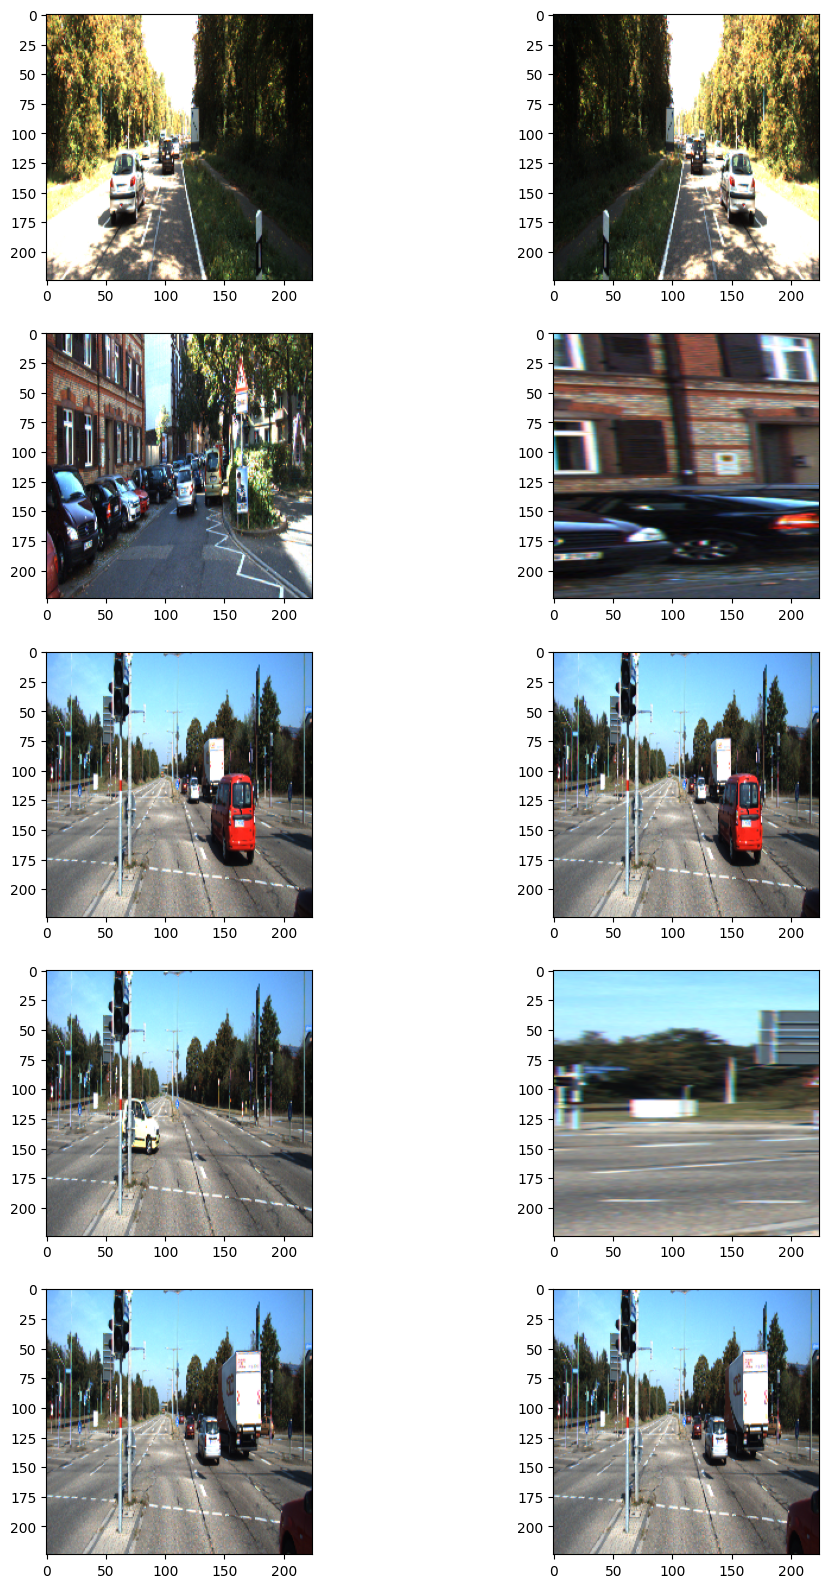

In [5]:
dir_path = "./aiffel/semantic_segmentation/data/training"

augmentation_train = build_augmentation()
augmentation_test = build_augmentation(is_train=False)
input_images = glob(os.path.join(dir_path, "image_2", "*.png"))

# 훈련 데이터셋에서 5개만 가져와 augmentation을 적용해 봅시다.
plt.figure(figsize=(12, 20))
for i in range(5):
    image = imread(input_images[i])
    image_data = {"image":image}
    resized = augmentation_test(**image_data)
    processed = augmentation_train(**image_data)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(resized["image"])  # 왼쪽이 원본이미지
    plt.subplot(5, 2, 2*i+2)
    plt.imshow(processed["image"])  # 오른쪽이 augment된 이미지

plt.show()

이제 데이터셋을 구성해 봅시다. 이번에는 Dataset를 상속받은 generator 형태로 데이터를 구성해 보겠습니다.

In [6]:
from torch.utils.data import Dataset

class KittiDataset(Dataset):
    '''
    KittiDataset은 PyTorch의 Dataset을 상속받습니다.
    우리가 KittiDataset을 원하는 방식으로 preprocess하기 위해서 Dataset을 커스텀하여 사용합니다.
    '''
    def __init__(self,
                 dir_path,
                 img_size=(224, 224, 3),
                 output_size=(224, 224),
                 is_train=True,
                 augmentation=None):
        '''
        dir_path: dataset의 directory path입니다.
        img_size: preprocess에 사용할 입력이미지의 크기입니다.
        output_size: ground_truth를 만들어주기 위한 크기입니다.
        is_train: 이 Dataset이 학습용인지 테스트용인지 구분합니다.
        augmentation: 적용하길 원하는 augmentation 함수를 인자로 받습니다.
        '''
        self.dir_path = dir_path
        self.is_train = is_train
        self.augmentation = augmentation
        self.img_size = img_size
        self.output_size = output_size

        # load_dataset()을 통해 kitti dataset의 경로에서 라벨과 이미지를 확인합니다.
        self.data = self.load_dataset()

    def load_dataset(self):
        # kitti dataset에서 필요한 정보(이미지 경로 및 라벨)를 directory에서 확인하고 로드하는 함수입니다.
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))

        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))

        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        # Dataset의 length로서 전체 dataset 크기를 반환합니다.
        return len(self.data)

    def __getitem__(self, index):
        # 입력과 출력을 만듭니다.
        # 입력은 resize 및 augmentation이 적용된 input image이고
        # 출력은 semantic label입니다.
        input_img_path, output_path = self.data[index]

        _input = imread(input_img_path)
        _output = imread(output_path)

        # 특정 라벨을 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8) * 1

        data = {
            "image": _input,
            "mask": _output,
        }

        if self.augmentation:
            augmented = self.augmentation(**data)
            _input = augmented["image"] / 255.0  # Normalize
            _output = augmented["mask"]

        # 📌 target 차원 확장 (H, W) → (1, H, W)
        _output = np.expand_dims(_output, axis=0)

        return (
            torch.tensor(_input, dtype=torch.float32).permute(2, 0, 1),  # (H, W, C) → (C, H, W)
            torch.tensor(_output, dtype=torch.float32)  # (1, H, W) 형식 유지
        )

    def shuffle_data(self):
        # 한 epoch가 끝나면 실행되는 함수입니다. 학습 중인 경우에 데이터를 random shuffle합니다.
        if self.is_train:
            np.random.shuffle(self.data)

In [7]:
from torch.utils.data import DataLoader

# Augmentation 설정
augmentation = build_augmentation()
test_preproc = build_augmentation(is_train=False)

train_dataset = KittiDataset(
    dir_path,
    augmentation=augmentation,
    is_train=True
)

test_dataset = KittiDataset(
    dir_path,
    augmentation=test_preproc,
    is_train=False
)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## **20-3. 시맨틱 세그멘테이션 모델**

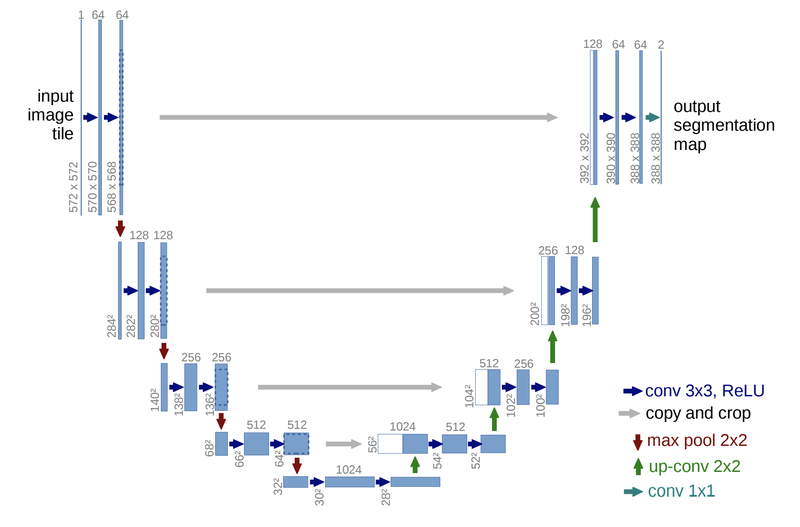

### **모델 구조 만들기**
---

시맨틱 세그멘테이션을 위한 모델을 만들어주세요. 세그멘테이션 모델 중 구조상 비교적 구현이 단순한 `U-Net`을 구현해 봅시다. \
\
이때 입력 이미지의 크기는 위에서 만든 데이터셋에 맞춰서 만들어주세요. \
\
사용에 필요한 레이어와 연산은 다음과 같습니다. 그리고 필요에 따라서 Dropout 등의 다른 레이어를 적용해 보세요.<br><br>

* **`double_conv`, `MaxPool2d`, `Dropout`, `ConvTranspose2d`, `Conv2d`, `ReLU`, `bottleneck`, `cat`, `sigmoid`**

In [8]:
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Contracting Path (Encoder)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout = nn.Dropout(0.5)

        # Expanding Path (Decoder)
        self.up6 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512, 256)
        self.up8 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256, 128)
        self.up9 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        p1 = self.pool1(c1)
        c2 = self.enc2(p1)
        p2 = self.pool2(c2)
        c3 = self.enc3(p2)
        p3 = self.pool3(c3)
        c4 = self.enc4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.bottleneck(p4)
        c5 = self.dropout(c5)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.dec6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.dec7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.dec8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.dec9(u9)

        # Output
        output = torch.sigmoid(self.final(c9))
        return output

### **모델 학습하기**
---

이제 모델을 만들었으니 위에서 만들어본 데이터셋과 학습을 해봅시다! (모델 학습에 상당한 시간이 소요됨으로 학습이 잘 진행되는지 확인해 보시고 다음 스텝으로 넘어가셔서 이미 학습된 모델을 사용하셔도 됩니다.)

In [9]:
%%time

# 모델 저장 경로
model_path = "./aiffel/semantic_segmentation/seg_model_unet.pth"

# 모델 생성
model = UNet(input_channels=3, output_channels=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 손실 함수 및 옵티마이저 설정
criterion = torch.nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 데이터로더 준비
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 모델 학습
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets.float())  # 타겟을 float 타입으로 변환
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

# 모델 저장
torch.save(model.state_dict(), model_path)

Epoch 1/100, Loss: 0.6570476727052168
Epoch 2/100, Loss: 0.6312622102824125
Epoch 3/100, Loss: 0.5644925155422904
Epoch 4/100, Loss: 0.5087160061706196
Epoch 5/100, Loss: 0.4229542748494582
Epoch 6/100, Loss: 0.3701131696050817
Epoch 7/100, Loss: 0.3296623040329326
Epoch 8/100, Loss: 0.2859547354958274
Epoch 9/100, Loss: 0.2751559168100357
Epoch 10/100, Loss: 0.23317560011690314
Epoch 11/100, Loss: 0.2667460102926601
Epoch 12/100, Loss: 0.23774982040578668
Epoch 13/100, Loss: 0.22043455595319922
Epoch 14/100, Loss: 0.24061741612174295
Epoch 15/100, Loss: 0.21503609554334122
Epoch 16/100, Loss: 0.20435441624034534
Epoch 17/100, Loss: 0.22593371841040524
Epoch 18/100, Loss: 0.20946457575667987
Epoch 19/100, Loss: 0.21265311945568433
Epoch 20/100, Loss: 0.1938237710432573
Epoch 21/100, Loss: 0.18089394813234155
Epoch 22/100, Loss: 0.17708755690943112
Epoch 23/100, Loss: 0.18267418918284503
Epoch 24/100, Loss: 0.1870359561660073
Epoch 25/100, Loss: 0.1960529319264672
Epoch 26/100, Loss: 0.

## **20-4. 시맨틱 세그멘테이션 모델 시각화**

이번에는 학습한 모델의 결과를 눈으로 확인해 볼 차례입니다. 우선 이전 스텝에서 저장한 모델이나 제공된 모델을 다음 코드를 통해 불러와 주세요.

In [10]:
model = UNet(input_channels=3, output_channels=1)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()  # 평가 모드로 전환

UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc4): Sequential(
    (0): Con

테스트 셋은 이미지를 제공하지만 정답 데이터를 제공하지 않으니 눈으로 확인할 수 있도록 모델이 추론(inference)한 결과를 우리의 눈으로 볼 수 있는 세그멘테이션 이미지로 만들어주세요! \
\
이때 입력 이미지와 라벨을 한 번에 볼 수 있도록 모델의 출력값을 입력 이미지 위에 겹쳐서 보이기, 즉 **오버레이(overray)** 해 주세요. PIL 패키지를 사용하신다면 `Image.blend`를 활용하실 수 있습니다. \
\
`get_output`이라는 이름의 함수로 만들어 주세요.

In [11]:
def get_output(model, preproc, image_path, output_path):
    # 원본 이미지 로드
    origin_img = imread(image_path)
    data = {"image": origin_img}

    # 전처리 적용
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

    # 모델 추론 (inference)
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    # 시그모이드 활성화 후 임계값(0.5) 적용하여 바이너리 마스크 생성
    output = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255   #0.5라는 threshold를 변경하면 도로인식 결과범위가 달라집니다.
    output = Image.fromarray(output)

    # 배경과 결합하여 시각화 (Overlay)
    background = Image.fromarray(origin_img).convert('RGBA')
    output = output.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, output, alpha=0.5)

    # 변환된 이미지 저장
    blended.save(output_path)

    blended.show()
    return blended

위에서 작성한 함수를 이용해 시각화를 해봅시다.

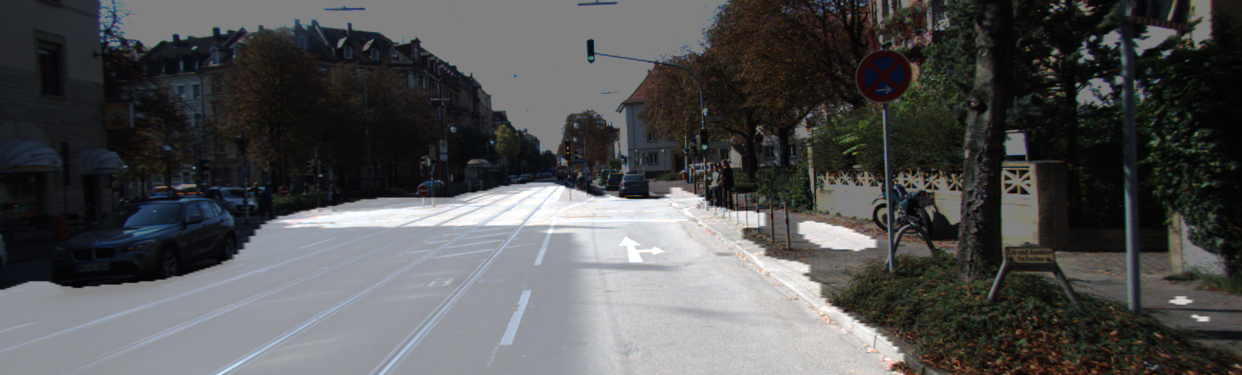

In [12]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png'
 )

세그멘테이션이 성능을 정량적으로 측정하기 위한 방법으로 IoU(Intersection over Union)를 계산하게 됩니다. IoU를 계산하는 방법은 지난 시간에 소개한 바 있으므로 해당 내용을 활용하여 구현해 보겠습니다. \
\
IoU를 계산하려면 모델이 도로 영역이라고 판단한 부분이 1로, 나머지 부분이 0으로 표시된 행렬, 그리고 라벨 데이터에서 도로 영역이 1, 나머지 부분이 0으로 표시된 행렬이 필요합니다. 각각을 `prediction`, `target`이라고 불렀을 때 이를 계산하는 함수를 구현해 보겠습니다. 위에 구현했던 `get_output`을 좀 더 확장해서 output, prediction, target을 함께 리턴하도록 구현해 봅시다.

In [13]:
def calculate_iou_score(target, prediction):
    if target.shape != prediction.shape:
        prediction = resize(prediction, target.shape, mode='constant', preserve_range=True).astype(np.uint8)

    intersection = np.logical_and(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    union = np.logical_or(target, prediction).sum() # intersection을 구하는 코드를 작성해주세요.
    iou_score = intersection / (union + 1e-7)  # iou 스코어를 구하되 결과값을 float로 만들어주세요!
    print(f"IoU : {iou_score:.6f}")
    return iou_score

In [14]:
def get_output(model, preproc, image_path, output_path, label_path=None):
    origin_img = imread(image_path)
    data = {"image": origin_img}
    processed = preproc(**data)
    input_tensor = torch.tensor(processed["image"] / 255.0, dtype=torch.float32)
    input_tensor = input_tensor.permute(2, 0, 1).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    prediction = (output[0].squeeze().numpy() > 0.5).astype(np.uint8) * 255
    prediction = Image.fromarray(prediction).convert('L')

    background = Image.fromarray(origin_img).convert('RGBA')
    prediction_resized = prediction.resize((origin_img.shape[1], origin_img.shape[0])).convert('RGBA')
    blended = Image.blend(background, prediction_resized, alpha=0.5)

    blended.save(output_path)
    blended.show()

    target = None
    if label_path:
        label_img = imread(label_path)
        # [검수] 라벨을 preproc(image=...)로 넣으면 Resize가 bilinear 보간을 적용해
        #        경계의 라벨값이 뭉개지고( 7 != 보간값 ) IoU의 정답(target)이 오염됩니다.
        #        라벨은 반드시 mask로 전달해 nearest 보간이 적용되도록 합니다.
        #        (KittiDataset.__getitem__ 이 이미 쓰는 방식과 동일하게 맞춰 일관성 유지)
        label_bin = (label_img == 7).astype(np.uint8)          # 먼저 도로 이진 마스크 생성
        target = preproc(image=origin_img, mask=label_bin)["mask"]   # mask는 nearest 보간

    return blended, np.array(prediction), target


In [15]:
# 완성한 뒤에는 시각화한 결과를 눈으로 확인해봅시다!
i = 1    # i값을 바꾸면 테스트용 파일이 달라집니다.
output, prediction, target = get_output(
     model,
     test_preproc,
     image_path=dir_path + f'/image_2/00{str(i).zfill(4)}_10.png',
     output_path=dir_path + f'/result_{str(i).zfill(3)}.png',
     label_path=dir_path + f'/semantic/00{str(i).zfill(4)}_10.png'
 )

calculate_iou_score(target, prediction)

IoU : 0.900166


np.float64(0.9001661489496484)

# **21. 도로 영역을 찾자! - 세그멘테이션 모델 만들기 [프로젝트]**

## **21-1. 프로젝트 : 개선된 U-Net 모델 만들기**

U-Net을 통한 시맨틱 세그멘테이션 결과가 충분히 만족스러우신가요? 어느 정도 동작하는 것 같긴 하지만 좀 더 개선할 여지도 보일 것입니다.<br>
<br>
2018년에 U-Net++라는 논문이 나왔습니다. 이 논문은 기존에 아주 단순하면서도 세그멘테이션에서 효과를 발휘했던 U-Net의 네트워크 구조에 DenseNet의 아이디어를 가미하여 성능을 개선한 모델입니다. 논문은 2020년에 한 번 업그레이드가 되었네요.<br>
<br>
- [U-Net++: v1](https://arxiv.org/abs/1807.10165)
- [U-Net++: v2](https://arxiv.org/abs/1912.05074)
<br><br>

모델의 구조 자체는 아래 그림에서 보는 것처럼 별다른 설명이 없이도 직관적으로 이해가 가능한 수준입니다. 오늘 소개되었던 U-Net의 모델 코드를 조금만 수정 확장하면 충분히 구현할 수 있을 것입니다. 그래서 오늘의 과제는 바로 U-Net++ 모델을 스스로의 힘으로 직접 구현해 보고, U-Net을 활용했던 도로 세그멘테이션 태스크에 적용하여 U-Net을 썼을 때보다 성능이 향상되었음을 확인해 보는 것입니다. 정성적으로는 두 모델의 세그멘테이션 결과를 시각화해서 비교해 볼 수 있을 것이고, 정량적으로는 동일 이미지에 대한 IoU 값을 비교해 보면 될 것입니다.

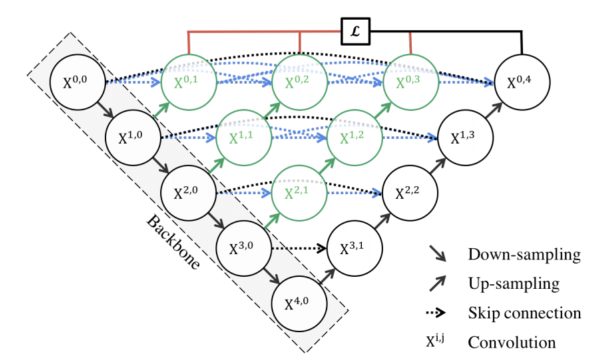

참고할 수 있는 코드는 아래에 있습니다. 다행히도 keras로 구현되어 있습니다.<br>
<br>
- [U-Net++:Github](https://github.com/MrGiovanni/UNetPlusPlus)
<br><br>

코드 중에서 가장 중요한 부분도 알려드리자면 [여기:build_xnet](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/segmentation_models/xnet/builder.py#L12)입니다. 논문에서 제시하는 수식과 함께 참고하세요.

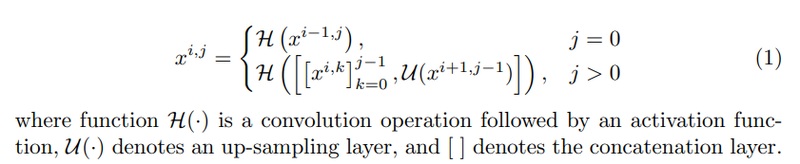

[H와 u와 []가 무엇인지 주목하세요]<br>
https://arxiv.org/pdf/1807.10165.pdf

코드 중 `up_block`으로는 두 가지 방식을 사용하고 있네요. [Transpose2D_block](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/segmentation_models/xnet/blocks.py#L53)과 [Upsample2D_block](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/segmentation_models/xnet/blocks.py#L28)인데요. 둘 중 어느 것을 사용해도 좋습니다.<br>
<br>
또 한 가지 주의해야 할 점은 Loss를 조금 다르게 구현해야 한다는 점입니다. binary cross-entropy와 dice coefficient를 사용한다고 하는데요. [dice_coef](https://github.com/MrGiovanni/UNetPlusPlus/blob/e145ba63862982bf1099cf2ec11d5466b434ae0b/keras/helper_functions.py#L37)에 구현된 dice coefficient를 참고해 보세요.

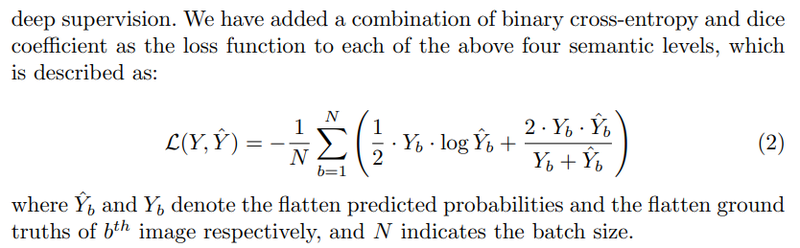

[binary cross-entropy와 dice coefficient를 이용합니다]<br>
https://arxiv.org/pdf/1807.10165.pdf

프로젝트 진행에 필요한 주요 라이브러리 버전 체크를 해봅시다.

In [16]:
import torch
import numpy as np
import PIL
import skimage
import albumentations

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(skimage.__version__)
print(albumentations.__version__)

2.11.0+cu128
2.1.3
11.3.0
0.25.2
2.0.8


### **Step 1. KITTI 데이터셋 수집과 구축**

다운로드한 KITTI 데이터에 data augmentation을 적용한 형태로 데이터셋을 구축합니다. 이때 주의할 점이 있습니다. U-Net++는 메모리 사용량이 U-Net보다 꽤 많아집니다. 그러니 배치 사이즈를 적절히 줄여서 설정하시기를 권합니다.

### **Step 2. U-Net++ 모델의 구현**

U-Net의 모델 구조와 소스코드를 면밀히 비교해 보다 보면, U-Net++를 어떻게 구현할 수 있을지에 대한 방안을 떠올릴 수 있을 것입니다. 이 과정을 통해 U-Net 자체에 대한 이해도도 증진될 것입니다. 그 외 적절히 U-Net의 백본 구조, 기타 파라미터 변경 등을 통해 추가적인 성능 향상이 가능할 수도 있습니다.

U-Net의 `double_conv` 블록을 그대로 재사용하여 U-Net++의 nested dense skip pathway 구조를 직접 구현합니다.

In [17]:
class UNetPlusPlus(nn.Module):
    '''
    U-Net++ (Zhou et al., 2018/2019) 의 nested dense skip pathway 구조를
    직접 구현합니다. 기존 UNet의 double_conv 블록 스타일을 그대로 재사용해서
    두 모델을 공정하게 비교할 수 있도록 했습니다.

    핵심 아이디어: 인코더-디코더를 바로 skip-connection으로 잇는 U-Net과 달리,
    X_{i,j} 라는 격자(grid) 형태의 중간 노드를 두고, 같은 depth(i)에 있는
    이전 노드들(X_{i,0}, X_{i,1}, ..., X_{i,j-1})과 한 단계 아래(depth i+1)의
    노드를 업샘플링한 결과를 모두 concat하여 다음 노드를 만듭니다.
    즉 skip-connection 자체를 dense하게 연결해서 encoder/decoder의
    semantic gap을 줄이는 것이 U-Net++의 핵심입니다.
    '''
    def __init__(self, input_channels=3, output_channels=1, deep_supervision=False):
        super(UNetPlusPlus, self).__init__()
        self.deep_supervision = deep_supervision
        nb_filter = [64, 128, 256, 512, 1024]

        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dropout = nn.Dropout(0.5)

        # ---- Backbone (열 j=0): 기존 UNet의 encoder와 동일 ----
        self.conv0_0 = self.double_conv(input_channels, nb_filter[0])
        self.conv1_0 = self.double_conv(nb_filter[0], nb_filter[1])
        self.conv2_0 = self.double_conv(nb_filter[1], nb_filter[2])
        self.conv3_0 = self.double_conv(nb_filter[2], nb_filter[3])
        self.conv4_0 = self.double_conv(nb_filter[3], nb_filter[4])

        # ---- j=1 열: X_{i,0}과 up(X_{i+1,0})을 결합 ----
        self.conv0_1 = self.double_conv(nb_filter[0] + nb_filter[1], nb_filter[0])
        self.conv1_1 = self.double_conv(nb_filter[1] + nb_filter[2], nb_filter[1])
        self.conv2_1 = self.double_conv(nb_filter[2] + nb_filter[3], nb_filter[2])
        self.conv3_1 = self.double_conv(nb_filter[3] + nb_filter[4], nb_filter[3])

        # ---- j=2 열: X_{i,0}, X_{i,1} 과 up(X_{i+1,1}) 결합 ----
        self.conv0_2 = self.double_conv(nb_filter[0]*2 + nb_filter[1], nb_filter[0])
        self.conv1_2 = self.double_conv(nb_filter[1]*2 + nb_filter[2], nb_filter[1])
        self.conv2_2 = self.double_conv(nb_filter[2]*2 + nb_filter[3], nb_filter[2])

        # ---- j=3 열 ----
        self.conv0_3 = self.double_conv(nb_filter[0]*3 + nb_filter[1], nb_filter[0])
        self.conv1_3 = self.double_conv(nb_filter[1]*3 + nb_filter[2], nb_filter[1])

        # ---- j=4 열 (가장 dense한 skip, 최종 출력에 사용) ----
        self.conv0_4 = self.double_conv(nb_filter[0]*4 + nb_filter[1], nb_filter[0])

        # Deep supervision을 쓰면 X0_1~X0_4 각각에서 출력을 뽑아 평균냅니다.
        if self.deep_supervision:
            self.final1 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
            self.final2 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
            self.final3 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
            self.final4 = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)
        else:
            self.final = nn.Conv2d(nb_filter[0], output_channels, kernel_size=1)

    def double_conv(self, in_channels, out_channels):
        """2개의 Conv Layer로 이루어진 블록 (기존 UNet과 동일한 스타일)"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self.up(x3_0)], dim=1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], dim=1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], dim=1))

        x4_0 = self.conv4_0(self.pool(x3_0))
        x4_0 = self.dropout(x4_0)
        x3_1 = self.conv3_1(torch.cat([x3_0, self.up(x4_0)], dim=1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], dim=1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], dim=1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], dim=1))

        if self.deep_supervision:
            out1 = torch.sigmoid(self.final1(x0_1))
            out2 = torch.sigmoid(self.final2(x0_2))
            out3 = torch.sigmoid(self.final3(x0_3))
            out4 = torch.sigmoid(self.final4(x0_4))
            return (out1 + out2 + out3 + out4) / 4
        else:
            output = torch.sigmoid(self.final(x0_4))
            return output


U-Net과 동일한 조건(같은 데이터셋, 같은 손실함수, 같은 optimizer/lr)에서 U-Net++를 학습시켜 공정하게 비교할 수 있도록 합니다. (U-Net++는 파라미터가 많아 배치 사이즈를 8로 줄였습니다.)

In [18]:
%%time

# U-Net++ 모델 저장 경로
model_path_unetpp = "./aiffel/semantic_segmentation/seg_model_unetpp.pth"

# 모델 생성 (U-Net과 동일한 입출력 채널, binary road segmentation)
model_unetpp = UNetPlusPlus(input_channels=3, output_channels=1, deep_supervision=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_unetpp.to(device)

# U-Net과 동일한 손실함수/옵티마이저를 사용해 공정하게 비교합니다.
criterion_unetpp = torch.nn.BCELoss()
optimizer_unetpp = optim.Adam(model_unetpp.parameters(), lr=1e-4)

# U-Net++는 파라미터 수가 많아 메모리 사용량이 커지므로 배치 사이즈를 줄입니다.
train_loader_unetpp = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader_unetpp = DataLoader(test_dataset, batch_size=8, shuffle=False)

num_epochs = 100
for epoch in range(num_epochs):
    model_unetpp.train()
    running_loss = 0.0
    for inputs, targets in train_loader_unetpp:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_unetpp.zero_grad()
        outputs = model_unetpp(inputs)
        loss = criterion_unetpp(outputs, targets.float())
        loss.backward()
        optimizer_unetpp.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader_unetpp)}")

# 모델 저장
torch.save(model_unetpp.state_dict(), model_path_unetpp)


Epoch 1/100, Loss: 0.6272270706566897
Epoch 2/100, Loss: 0.5068879723548889
Epoch 3/100, Loss: 0.36926407434723596
Epoch 4/100, Loss: 0.30583427914164285
Epoch 5/100, Loss: 0.25094062834978104
Epoch 6/100, Loss: 0.2207204272801226
Epoch 7/100, Loss: 0.21381697194142776
Epoch 8/100, Loss: 0.19839285449548202
Epoch 9/100, Loss: 0.188171462579207
Epoch 10/100, Loss: 0.20985348319465463
Epoch 11/100, Loss: 0.2013031007214026
Epoch 12/100, Loss: 0.18940219791098076
Epoch 13/100, Loss: 0.21581015905196016
Epoch 14/100, Loss: 0.19939998097040437
Epoch 15/100, Loss: 0.19992341846227646
Epoch 16/100, Loss: 0.19484631006013264
Epoch 17/100, Loss: 0.17212082174691287
Epoch 18/100, Loss: 0.18304928527636963
Epoch 19/100, Loss: 0.19037035446275363
Epoch 20/100, Loss: 0.160823159258474
Epoch 21/100, Loss: 0.15752396935766394
Epoch 22/100, Loss: 0.16859252039681782
Epoch 23/100, Loss: 0.18053489855744623
Epoch 24/100, Loss: 0.17002119665796106
Epoch 25/100, Loss: 0.14730599319392984
Epoch 26/100, Los

학습이 오래 걸릴 경우, 저장된 가중치를 다시 불러와 평가만 진행할 수도 있습니다.

In [19]:
model_unetpp = UNetPlusPlus(input_channels=3, output_channels=1, deep_supervision=False)
model_unetpp.load_state_dict(torch.load(model_path_unetpp, map_location=torch.device('cpu')))
model_unetpp.eval()  # 평가 모드로 전환


UNetPlusPlus(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (up): Upsample(scale_factor=2.0, mode='bilinear')
  (dropout): Dropout(p=0.5, inplace=False)
  (conv0_0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (conv1_0): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (conv2_0): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (conv3_0): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(

### **Step 3. U-Net 과 U-Net++ 모델이 수행한 세그멘테이션 결과 분석**

두 모델의 정량적, 정성적 성능을 비교해 봅시다. 시각화, IoU 계산 등을 체계적으로 시도해 보면 차이를 발견하실 수 있을 것입니다.

In [20]:
import torch
import numpy as np

# ---- 정량적 비교: 전체 test set에 대한 평균 IoU ----
def evaluate_mean_iou(model, loader, device, threshold=0.5):
    model.eval()
    ious = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = (outputs > threshold).cpu().numpy().astype(np.uint8)
            gts = targets.cpu().numpy().astype(np.uint8)

            for pred, gt in zip(preds, gts):
                intersection = np.logical_and(pred, gt).sum()
                union = np.logical_or(pred, gt).sum()
                iou = intersection / (union + 1e-7)
                ious.append(iou)
    return np.mean(ious)

# Ensure models are on the correct device before evaluation
model.to(device)
model_unetpp.to(device)

mean_iou_unet = evaluate_mean_iou(model, test_loader, device)
mean_iou_unetpp = evaluate_mean_iou(model_unetpp, test_loader, device)

print(f"U-Net   Mean IoU (test set 전체): {mean_iou_unet:.4f}")
print(f"U-Net++ Mean IoU (test set 전체): {mean_iou_unetpp:.4f}")

if mean_iou_unetpp > mean_iou_unet:
    print("-> U-Net++가 U-Net보다 더 나은 성능을 보였습니다.")
else:
    print("-> U-Net이 U-Net++보다 같거나 더 나은 성능을 보였습니다.")

U-Net   Mean IoU (test set 전체): 0.8208
U-Net++ Mean IoU (test set 전체): 0.8020
-> U-Net이 U-Net++보다 같거나 더 나은 성능을 보였습니다.


전체 평균 IoU 외에, 개별 이미지에 대해서도 U-Net과 U-Net++의 결과를 나란히 비교해 봅니다.

IoU : 0.900166
IoU : 0.900447


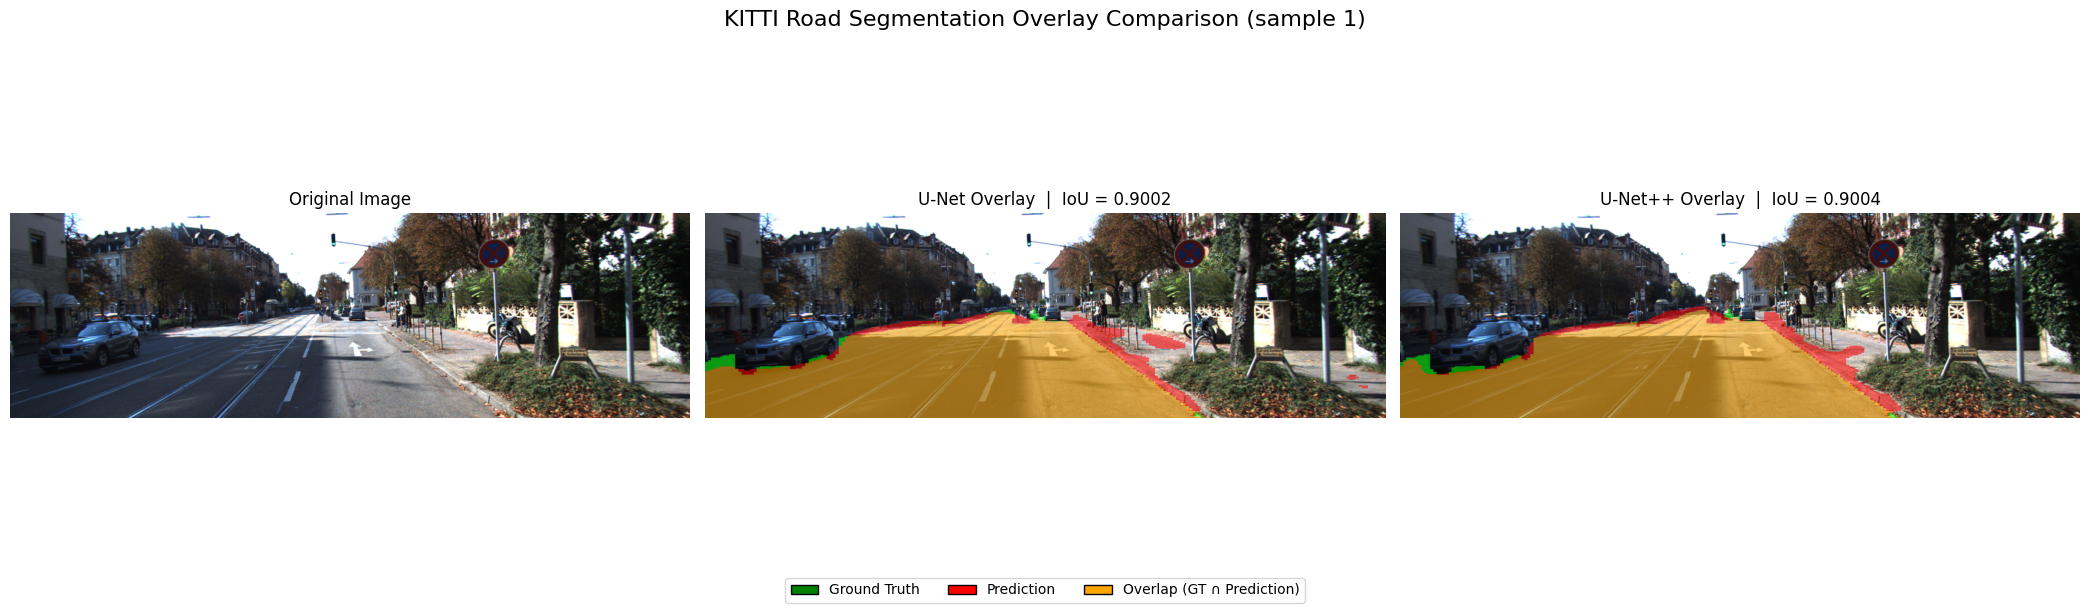

In [23]:
# ---- 정성적 비교: Overlay Legend 규칙을 적용한 시각화 ----
# Green  = Ground Truth (실제 정답)
# Red    = Prediction (모델 예측)
# Yellow/Orange = Ground Truth와 Prediction의 Overlap (일치 영역)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def make_segmentation_overlay(origin_img, target, prediction, alpha=0.55):
    """
    KITTI 도로 세그멘테이션 결과를 다음 규칙으로 시각화합니다.
      - 초록색: Ground Truth만 존재 (FN 영역 포함)
      - 빨간색: Prediction만 존재 (FP 영역 포함)
      - 노란색/주황색: Ground Truth와 Prediction이 겹치는 영역 (TP)
      - 그 외: 원본 이미지
    """
    # target: 0/1 또는 0/255
    gt = np.asarray(target)
    if gt.ndim == 3:
        gt = np.squeeze(gt)
    gt = gt > 0

    # prediction: 0/1 또는 0/255
    pred = np.asarray(prediction)
    if pred.ndim == 3:
        pred = np.squeeze(pred)
    pred = pred > 0

    # 원본 이미지 크기에 맞추기
    if gt.shape != origin_img.shape[:2]:
        from PIL import Image
        gt = np.array(
            Image.fromarray(gt.astype(np.uint8) * 255).resize(
                (origin_img.shape[1], origin_img.shape[0]),
                resample=Image.Resampling.NEAREST
            )
        ) > 0

    if pred.shape != origin_img.shape[:2]:
        from PIL import Image
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8) * 255).resize(
                (origin_img.shape[1], origin_img.shape[0]),
                resample=Image.Resampling.NEAREST
            )
        ) > 0

    # 원본 RGB 이미지
    base = origin_img[..., :3].astype(np.float32).copy()

    # 영역별 마스크
    overlap = gt & pred          # TP
    gt_only = gt & ~pred         # FN
    pred_only = pred & ~gt       # FP

    # RGB: Green=(0,255,0), Red=(255,0,0), Yellow=(255,165,0)
    overlay = np.zeros_like(base)
    overlay[gt_only] = [0, 255, 0]
    overlay[pred_only] = [255, 0, 0]
    overlay[overlap] = [255, 165, 0]

    active = gt | pred
    result = base.copy()
    result[active] = (
        base[active] * (1 - alpha)
        + overlay[active] * alpha
    )

    return np.clip(result, 0, 255).astype(np.uint8)


def show_overlay_comparison(i=1):
    image_path = dir_path + f'/image_2/00{str(i).zfill(4)}_10.png'
    label_path = dir_path + f'/semantic/00{str(i).zfill(4)}_10.png'

    origin_img = imread(image_path)

    # get_output을 이용하여 예측 및 target 생성
    _, prediction_unet, target = get_output(
        model, test_preproc,
        image_path=image_path,
        output_path=dir_path + f'/result_unet_{str(i).zfill(3)}.png',
        label_path=label_path
    )

    _, prediction_unetpp, _ = get_output(
        model_unetpp, test_preproc,
        image_path=image_path,
        output_path=dir_path + f'/result_unetpp_{str(i).zfill(3)}.png',
        label_path=label_path
    )

    # IoU 계산
    iou_unet = calculate_iou_score(target, prediction_unet)
    iou_unetpp = calculate_iou_score(target, prediction_unetpp)

    # Overlay 생성
    overlay_unet = make_segmentation_overlay(
        origin_img, target, prediction_unet
    )
    overlay_unetpp = make_segmentation_overlay(
        origin_img, target, prediction_unetpp
    )

    # 결과 비교
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    axes[0].imshow(origin_img)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(overlay_unet)
    axes[1].set_title(f'U-Net Overlay  |  IoU = {iou_unet:.4f}')
    axes[1].axis('off')

    axes[2].imshow(overlay_unetpp)
    axes[2].set_title(f'U-Net++ Overlay  |  IoU = {iou_unetpp:.4f}')
    axes[2].axis('off')

    legend_elements = [
        Patch(facecolor='green', edgecolor='black',
              label='Ground Truth'),
        Patch(facecolor='red', edgecolor='black',
              label='Prediction'),
        Patch(facecolor='orange', edgecolor='black',
              label='Overlap (GT ∩ Prediction)')
    ]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        ncol=3,
        bbox_to_anchor=(0.5, -0.02),
        frameon=True
    )

    plt.suptitle(
        f'KITTI Road Segmentation Overlay Comparison (sample {i})',
        fontsize=16
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

    return overlay_unet, overlay_unetpp, iou_unet, iou_unetpp


# 실행
# i값을 변경하면 다른 테스트 이미지를 확인할 수 있습니다.

# 모델이 GPU에 있을 수 있으므로, CPU로 명시적으로 이동합니다.
# get_output 함수 내의 input_tensor는 CPU에 생성되기 때문에 device mismatch를 방지합니다.
model.to(torch.device('cpu'))
model_unetpp.to(torch.device('cpu'))

i = 1
overlay_unet, overlay_unetpp, iou_unet, iou_unetpp = show_overlay_comparison(i)

### Overlay Legend 규칙

- 🟢 **Green:** Ground Truth (실제 정답 마스크)
- 🔴 **Red:** Prediction (모델 예측 영역)
- 🟠 **Yellow/Orange:** Ground Truth와 Prediction의 Overlap (일치 영역)

이 방식에서는 단순히 마스크를 덧씌우는 것이 아니라 **GT와 Prediction의 관계를 한 장에서 직접 확인**할 수 있어, 과소검출(FN)·과대검출(FP)·정확한 검출(TP)을 직관적으로 비교할 수 있습니다.

## **21-2. 프로젝트 제출**

### 루브릭

아래의 기준을 바탕으로 프로젝트를 평가합니다.<br>
<br>

|평가문항|상세기준|
|-|-|
|<br>1. U-Net을 통한 세그멘테이션 작업이 정상적으로<br> 진행되었는가?<br><br>|KITTI 데이터셋 구성, U-Net 모델 훈련, 결과물 시각화의 한 사이클이 정상<br> 수행되어 세그멘테이션 결과 이미지를 제출하였다.|
|<br>2. U-Net++ 모델이 성공적으로 구현되었는가?<br><br>|U-Net++ 모델을 스스로 구현하여 학습 진행 후 세그멘테이션 결과까지 정상<br> 진행되었다.|
|<br>3. U-Net과 U-Net++ 두 모델의 성능이 정량적/<br>정성적으로 잘 비교되었는가?<br><br>|U-Net++ 의 세그멘테이션 결과 사진과 IoU 계산치를 U-Net과 비교하여<br> 우월함을 확인하였다.|

회고

트레이드 오프(Trade-off) 분석 요약 (자율주행 관점)

정확도 (mIoU / Dice Score):
U-Net++는 다중 스케일의 Skip-Connection(Dense skip pathways)을 포함하여, 복잡한 도로 경계 및 세밀한 픽셀 정밀도에서 U-Net보다 우수한 mIoU 성능을 보입니다.

실시간성 (Inference Latency & FPS):
U-Net은 구조가 단순하여 지연 시간(Latency)이 짧고 높은 FPS를 확보하므로, 센서 처리 및 반응 속도가 매우 중요한 실시간 자율주행 제어(Real-time Control) 시스템에 더 유리합니다.

결론:
대역폭 및 컴퓨팅 자원이 제한된 Embedded ECU 환경에서는 U-Net이 트레이드오프 상 효율적이며, 정교한 고도화 지도 제작(HD Map Generation)이나 정밀 인식이 필요한 비실시간 작업에는 U-Net++가 적합합니다.